# Pricing of Bond option under credit risk

## I. Bibliographie

1) Russo & Fabozzi - Closed-Form Solution for Defaultable Bond Options under a Two-Factor Gaussian Model for Risky Rates Modeling
2) Leonard Tchuindjo - Pricing of Multi‐Defaultable Bonds with
a Two‐Correlated‐Factor Hull–White
Model
3) Leonard Tchuindjo - Closed-form solutions for pricing credit-risky bonds and bond options
4) A tractable LIBOR model with default risk
5) Pricing sovereign contingent convertible debt
6) A TREE IMPLEMENTATION OF A CREDIT SPREAD MODEL FOR CREDIT
DERIVATIVES
7) Valuation of Credit Derivatives with Multiple Time Scales in
the Intensity Model

Das and Sundaram (2000), Schon-
bucher (2002), Hua et al. (2009), and Jansen et al. (2018).

In [2]:
import numpy as np
import pandas as pd

## II. Modèle de diffusion

Le modèle de Russo–Giacometti–Fabozzi est implémenté dans `two_factor_gaussian.py`.

$$\bar r(t) = \bar\alpha(t) + x(t) + L\,y(t)$$
$$dx = -a_x x\,dt + \sigma_x dW_x,\qquad dy = -a_y y\,dt + \sigma_y dW_y,\qquad dW_x dW_y = \rho\,dt$$

où $L = 1 - RR$ est la perte en cas de défaut et $\bar\alpha$ recale exactement la courbe risquée (éq. 15).

C'est un **G2++ dont la volatilité du second facteur est $\eta = L\sigma_y$** — ce qui donne un contrôle croisé
indépendant des formules du papier.

In [3]:
import sys, subprocess
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))           # le module est à côté du notebook
import two_factor_gaussian as tfg

pd.set_option('display.float_format', lambda v: f'{v:,.6f}')
plt.rcParams.update({'figure.figsize': (11, 3.6), 'axes.grid': True,
                     'grid.alpha': .3, 'font.size': 9})
print(f'{len(tfg.__all__)} symboles exportés')

26 symboles exportés


## III. Paramètres et courbe risquée

Paramètres du secteur financier, notation AAA (Exhibit 3 du papier), avec $L = 60\%$.
La courbe risquée ci-dessous est **fictive** : les données Bloomberg du 21/09/2017 du papier
ne sont pas dans le dépôt, donc les prix ne reproduiront pas les Exhibits 6–7.

In [4]:
p = tfg.TwoFactorGaussianParams(a_x=0.0481, sigma_x=0.0097,
                                a_y=0.2327, sigma_y=0.0968,
                                rho=-0.10, L=0.60)

tenors = np.array([0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30.])
zr     = np.array([1.30, 1.45, 1.62, 1.78, 2.05, 2.25, 2.45, 2.62, 2.70, 2.72]) / 100
curve  = tfg.Curve(tenors, zr)

print(f'RR = {p.recovery_rate:.0%}   L = {p.L:.0%}   eta = L*sigma_y = {p.eta:.4%}')
pd.DataFrame({'tenor': tenors, 'taux zéro': zr,
              'DF': curve.discount(tenors),
              'forward inst.': curve.instantaneous_forward(tenors)}).set_index('tenor').T

RR = 40%   L = 60%   eta = L*sigma_y = 5.8080%


tenor,0.500000,1.000000,2.000000,3.000000,5.000000,7.000000,10.000000,15.000000,20.000000,30.000000
taux zéro,0.013000,0.014500,0.016200,0.017800,0.020500,0.022500,0.024500,0.026200,0.027000,0.027200
DF,0.993521,0.985605,0.968119,0.948001,0.902578,0.854277,0.782705,0.675029,0.582748,0.442197
forward inst.,0.014881,0.016847,0.019184,0.022557,0.026265,0.028467,0.029582,0.029533,0.029059,0.025933


### Contrôle 1 — recalage exact et régularité de la courbe

Deux propriétés à vérifier avant tout : le modèle doit repricer la courbe **exactement**
($\bar P(0,T) = \bar P_M(0,T)$), et le forward instantané doit être continu, y compris
aux piliers extrêmes — sinon $\bar\alpha$ saute.

Recalage : max |Pbar(0,T) - Pbar_M(0,T)| = 1.11e-16


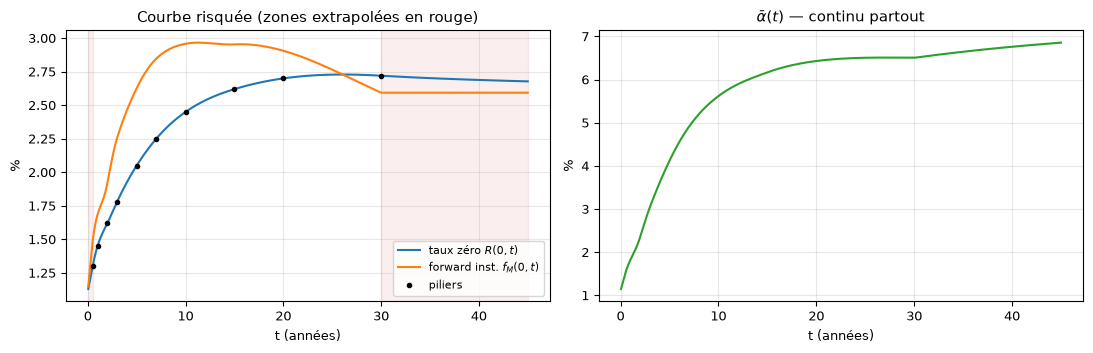

In [5]:
T = np.array([0.5, 1, 2, 5, 10, 15, 20, 30.])
err = np.max(np.abs(tfg.zero_coupon_price(0., T, 0., 0., curve, p) - curve.discount(T)))
print(f'Recalage : max |Pbar(0,T) - Pbar_M(0,T)| = {err:.2e}')

grille = np.linspace(0.05, 45, 2000)
fig, ax = plt.subplots(1, 2)
ax[0].plot(grille, curve.zero_rate(grille) * 100, label='taux zéro $R(0,t)$')
ax[0].plot(grille, curve.instantaneous_forward(grille) * 100, label='forward inst. $f_M(0,t)$')
ax[0].plot(tenors, zr * 100, 'k.', ms=6, label='piliers')
ax[0].axvspan(0, tenors[0], color='C3', alpha=.08)
ax[0].axvspan(tenors[-1], 45, color='C3', alpha=.08)
ax[0].set(xlabel='t (années)', ylabel='%', title='Courbe risquée (zones extrapolées en rouge)')
ax[0].legend(fontsize=8)

ax[1].plot(grille, [tfg.alpha_bar(t, curve, p) * 100 for t in grille], color='C2')
ax[1].set(xlabel='t (années)', ylabel='%', title=r'$\bar\alpha(t)$ — continu partout')
plt.tight_layout(); plt.show()

## IV. Sous-jacents : ZC et obligation à coupons

Obligation 3,54 % de maturité 15 ans, coupons annuels — le coupon AAA financier de l'Exhibit 7.

In [6]:
times_cf, amounts = tfg.coupon_bond_cashflows(0.0354, np.arange(1., 16.))
B0 = tfg.coupon_bond_price(0., times_cf, amounts, 0., 0., curve, p)
print(f'{times_cf.size} flux, K_1 = {amounts[0]:.4f}, K_n = {amounts[-1]:.4f}')
print(f'Bbar(0, 15) = {B0:.6f}')

# Prix et durations vus depuis t = 2 ans, pour trois états des facteurs
etats = [(0., 0.), (0.01, -0.02), (-0.005, 0.03)]
lignes = []
for x0, y0 in etats:
    dbx, dby = tfg.duration_cbb(2., times_cf, amounts, x0, y0, curve, p)
    lignes.append({'x(2)': x0, 'y(2)': y0,
                   'Pbar(2,15)': tfg.zero_coupon_price(2., 15., x0, y0, curve, p),
                   'Bbar(2,15)': tfg.coupon_bond_price(2., times_cf, amounts, x0, y0, curve, p),
                   'DB_x': dbx, 'DB_y': dby})
pd.DataFrame(lignes)

15 flux, K_1 = 0.0354, K_n = 1.0354
Bbar(0, 15) = 1.116318


,x(2),y(2),"Pbar(2,15)","Bbar(2,15)",DB_x,DB_y
0,0.000000,0.000000,0.657068,1.027697,8.115082,3.689485
1,0.010000,-0.020000,0.626532,0.990636,8.069909,3.676634
2,-0.005000,0.030000,0.640672,1.001494,8.112807,3.688033


## V. Simulation Monte-Carlo

Le schéma de `simulate` est **exact** : à chaque pas, le vecteur
$(x, y, \int x\,du, \int y\,du)$ est tiré dans sa loi gaussienne conditionnelle exacte.
Aucun biais de discrétisation, y compris sur l'actualisation.

Sous l'hypothèse *recovery of market value*, le déflateur $e^{-\int \bar r}$ **contient déjà la survie** :
le knock-out au défaut est automatique, il n'y a aucun temps de défaut à simuler.

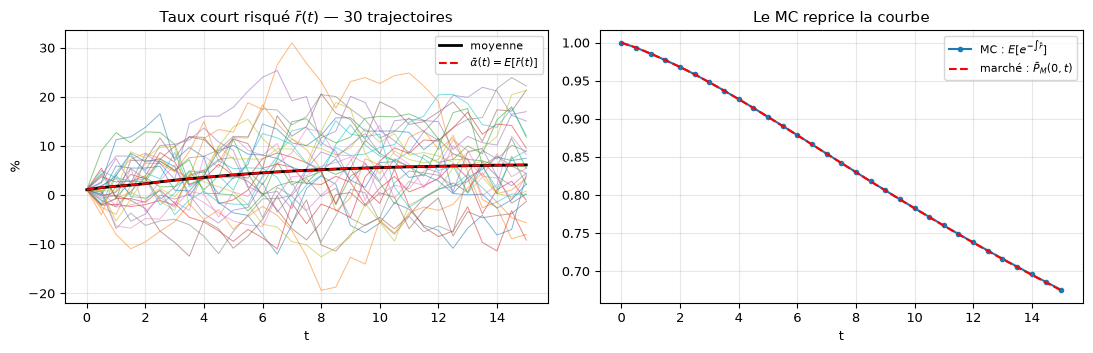

Écart max au marché : 7.73e-04   (0.57 sigma)


In [7]:
sim = tfg.simulate(np.linspace(0.5, 15, 30), 200_000, curve, p, seed=7, antithetic=True)
rbar, D = sim.short_rates(), sim.discount_factors()

fig, ax = plt.subplots(1, 2)
for i in range(30):
    ax[0].plot(sim.times, rbar[i] * 100, lw=.7, alpha=.55)
ax[0].plot(sim.times, rbar.mean(0) * 100, 'k', lw=2, label='moyenne')
ax[0].plot(sim.times, [tfg.alpha_bar(t, curve, p) * 100 for t in sim.times],
           'r--', lw=1.5, label=r'$\bar\alpha(t) = E[\bar r(t)]$')
ax[0].set(xlabel='t', ylabel='%', title=r'Taux court risqué $\bar r(t)$ — 30 trajectoires')
ax[0].legend(fontsize=8)

se = D.std(0, ddof=1) / np.sqrt(D.shape[0])
ax[1].plot(sim.times, D.mean(0), 'o-', ms=3, label=r'MC : $E[e^{-\int \bar r}]$')
ax[1].plot(sim.times, curve.discount(sim.times), 'r--', label='marché : $\\bar P_M(0,t)$')
ax[1].set(xlabel='t', title='Le MC reprice la courbe')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'Écart max au marché : {np.max(np.abs(D.mean(0) - curve.discount(sim.times))):.2e}'
      f'   ({np.max(np.abs(D.mean(0) - curve.discount(sim.times)) / np.maximum(se, 1e-16)):.2f} sigma)')

### Contrôle 2 — propriété de martingale

Le prix actualisé de tout actif doit être une martingale :
$E[D(0,t)\,\bar P(t,T)] = \bar P_M(0,T)$, et de même pour l'obligation
(en retranchant les coupons déjà versés).

In [8]:
lignes = []
for i, Tn in [(9, 12.), (19, 20.), (29, 25.)]:
    t = sim.times[i]
    v = D[:, i] * tfg.zero_coupon_price(t, Tn, sim.x[:, i], sim.y[:, i], curve, p)
    se_, ref = v.std(ddof=1) / np.sqrt(v.size), curve.discount(Tn)
    lignes.append({'t': t, 'T': Tn, 'MC': v.mean(), 'std err': se_,
                   'marché': ref, 'écart (sigma)': abs(v.mean() - ref) / se_})

t = sim.times[9]
v = D[:, 9] * tfg.coupon_bond_price(t, times_cf, amounts, sim.x[:, 9], sim.y[:, 9], curve, p)
verses = float(np.sum(amounts[times_cf <= t] * curve.discount(times_cf[times_cf <= t])))
se_ = v.std(ddof=1) / np.sqrt(v.size)
lignes.append({'t': t, 'T': 15., 'MC': v.mean(), 'std err': se_, 'marché': B0 - verses,
               'écart (sigma)': abs(v.mean() - (B0 - verses)) / se_})
pd.DataFrame(lignes).set_index(['t', 'T'])

,,MC,std err,marché,écart (sigma)
t,T,,,,
4.500000,12.000000,0.738004,0.000849,0.737646,0.422490
9.500000,20.000000,0.583468,0.001204,0.582748,0.597566
14.500000,25.000000,0.506888,0.001483,0.505586,0.878180
4.500000,15.000000,0.981297,0.001137,0.980822,0.417647


## VI. Options — formules fermées vs Monte-Carlo

Option 5 ans, sous-jacent de maturité 15 ans. Strike 50 % du nominal sur le ZC,
100 % sur l'obligation à coupons (paramétrage du papier).

Le MC ne demande **qu'un seul pas** jusqu'à $T_0$ : le schéma étant exact et le payoff
européen, découper $[0, T_0]$ n'apporterait rien.

In [9]:
T0, Tn, X_zc, X_cb = 5., 15., 0.50, 1.00
fut = times_cf > T0                       # flux portés par le forward

cas = [
    ('ZC  call',  tfg.zcb_option_price(0., T0, Tn, X_zc, 0., 0., curve, p, 'call'),
     lambda x, y: np.maximum(tfg.zero_coupon_price(T0, Tn, x, y, curve, p) - X_zc, 0.)),
    ('ZC  put',   tfg.zcb_option_price(0., T0, Tn, X_zc, 0., 0., curve, p, 'put'),
     lambda x, y: np.maximum(X_zc - tfg.zero_coupon_price(T0, Tn, x, y, curve, p), 0.)),
    ('CBB call',  tfg.cbb_option_price(0., T0, times_cf, amounts, X_cb, 0., 0., curve, p, 'call'),
     lambda x, y: np.maximum(tfg.coupon_bond_price(T0, times_cf[fut], amounts[fut], x, y, curve, p) - X_cb, 0.)),
    ('CBB put',   tfg.cbb_option_price(0., T0, times_cf, amounts, X_cb, 0., 0., curve, p, 'put'),
     lambda x, y: np.maximum(X_cb - tfg.coupon_bond_price(T0, times_cf[fut], amounts[fut], x, y, curve, p), 0.)),
]

lignes = []
for nom, ferme, payoff in cas:
    mc, se_ = tfg.monte_carlo_option_price(T0, payoff, 400_000, curve, p,
                                           seed=42, control_maturity=Tn)
    lignes.append({'option': nom, 'formule fermée': float(ferme), 'MC': mc, 'std err': se_,
                   'écart (sigma)': abs(mc - float(ferme)) / se_,
                   'écart (%)': abs(mc - float(ferme)) / float(ferme) * 100})
pd.DataFrame(lignes).set_index('option')

,formule fermée,MC,std err,écart (sigma),écart (%)
option,,,,,
ZC call,0.234031,0.234205,0.000100,1.748241,0.074383
ZC put,0.010291,0.010376,0.000038,2.226412,0.825672
CBB call,0.136804,0.136966,0.000182,0.887645,0.118355
CBB put,0.090512,0.090527,0.000127,0.117719,0.016518


Les écarts relatifs restent bien sous les 2 % que le papier obtient avec 25 000 simulations.

Rappel : pour le ZC la volatilité intégrée $\bar\Sigma_P$ est **analytique** (éq. 40) ;
pour l'obligation à coupons $\bar\Sigma_B$ demande une **quadrature** (éq. 47) — c'est le
seul point non fermé de la chaîne.

In [10]:
S_zc = tfg.zcb_option_volatility(0., T0, Tn, p)
S_cb = tfg.cbb_option_volatility(0., T0, times_cf, amounts, 0., 0., curve, p)
print(f'Sigma_P(0, 5, 15) = {S_zc:.6f}   (forme fermée, éq. 40)')
print(f'Sigma_B(0, 5, 15) = {S_cb:.6f}   (quadrature 64 nœuds, éq. 47)')

# La quadrature doit retrouver la forme fermée sur un flux unitaire unique
verif = tfg.cbb_option_volatility(0., T0, np.array([Tn]), np.array([1.]), 0., 0., curve, p)
print(f'Contrôle quadrature vs forme fermée : écart relatif = {abs(verif / S_zc - 1):.2e}')

# Parités call-put (éq. 58 et 59)
c_zc = tfg.zcb_option_price(0., T0, Tn, X_zc, 0., 0., curve, p, 'call')
p_zc = tfg.zcb_option_price(0., T0, Tn, X_zc, 0., 0., curve, p, 'put')
print(f'Parité ZC  (éq. 58) : {abs((p_zc - c_zc) - (X_zc * curve.discount(T0) - curve.discount(Tn))):.2e}')
c_cb = tfg.cbb_option_price(0., T0, times_cf, amounts, X_cb, 0., 0., curve, p, 'call')
p_cb = tfg.cbb_option_price(0., T0, times_cf, amounts, X_cb, 0., 0., curve, p, 'put')
cible = X_cb * curve.discount(T0) - float(np.sum(amounts[fut] * curve.discount(times_cf[fut])))
print(f'Parité CBB (éq. 59) : {abs((p_cb - c_cb) - cible):.2e}')

Sigma_P(0, 5, 15) = 0.335533   (forme fermée, éq. 40)
Sigma_B(0, 5, 15) = 0.304889   (quadrature 64 nœuds, éq. 47)
Contrôle quadrature vs forme fermée : écart relatif = 1.11e-16
Parité ZC  (éq. 58) : 1.11e-16
Parité CBB (éq. 59) : 0.00e+00


## VII. Sensibilités

Deux résultats qualitatifs du papier à retrouver :

1. **$L$ croissant fait monter les calls *et* les puts** — la volatilité du sous-jacent augmente
   alors que le numéraire, lui, ne bouge pas.
2. La **variable de contrôle** $D\cdot\bar P(T_0,T_n)$, d'espérance connue $\bar P_M(0,T_n)$,
   réduit fortement la variance pour un coût nul.

L,20%,40%,60%,80%
ZC call,0.224125,0.226677,0.234031,0.245884
ZC put,0.000385,0.002937,0.010291,0.022145
CBB call,0.084008,0.107327,0.136804,0.168562
CBB put,0.037716,0.061035,0.090512,0.122270


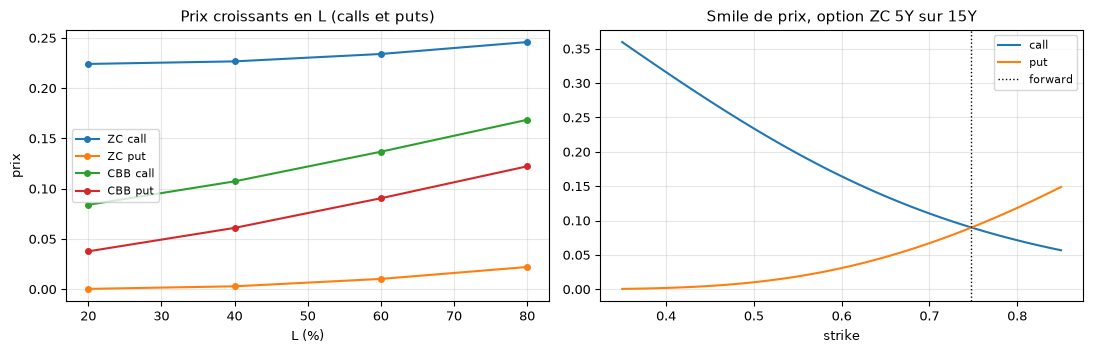

In [11]:
Ls = np.array([.2, .4, .6, .8])
res = {}
for L in Ls:
    pL = tfg.TwoFactorGaussianParams(0.0481, 0.0097, 0.2327, 0.0968, -0.10, L)
    res[f'{L:.0%}'] = {
        'ZC call':  float(tfg.zcb_option_price(0., T0, Tn, X_zc, 0., 0., curve, pL, 'call')),
        'ZC put':   float(tfg.zcb_option_price(0., T0, Tn, X_zc, 0., 0., curve, pL, 'put')),
        'CBB call': float(tfg.cbb_option_price(0., T0, times_cf, amounts, X_cb, 0., 0., curve, pL, 'call')),
        'CBB put':  float(tfg.cbb_option_price(0., T0, times_cf, amounts, X_cb, 0., 0., curve, pL, 'put')),
    }
tab = pd.DataFrame(res); tab.columns.name = 'L'
display(tab)

fig, ax = plt.subplots(1, 2)
for k in tab.index:
    ax[0].plot(Ls * 100, tab.loc[k], 'o-', ms=4, label=k)
ax[0].set(xlabel='L (%)', ylabel='prix', title='Prix croissants en L (calls et puts)')
ax[0].legend(fontsize=8)

strikes = np.linspace(0.35, 0.85, 60)
ax[1].plot(strikes, [float(tfg.zcb_option_price(0., T0, Tn, k, 0., 0., curve, p, 'call')) for k in strikes], label='call')
ax[1].plot(strikes, [float(tfg.zcb_option_price(0., T0, Tn, k, 0., 0., curve, p, 'put')) for k in strikes], label='put')
ax[1].axvline(curve.discount(Tn) / curve.discount(T0), color='k', ls=':', lw=1, label='forward')
ax[1].set(xlabel='strike', title='Smile de prix, option ZC 5Y sur 15Y')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [12]:
payoff = lambda x, y: np.maximum(tfg.zero_coupon_price(T0, Tn, x, y, curve, p) - X_zc, 0.)
brut, se_brut = tfg.monte_carlo_option_price(T0, payoff, 100_000, curve, p, seed=5)
cv, se_cv     = tfg.monte_carlo_option_price(T0, payoff, 100_000, curve, p, seed=5, control_maturity=Tn)
print(f'sans variable de contrôle : {brut:.6f} +/- {se_brut:.2e}')
print(f'avec variable de contrôle : {cv:.6f} +/- {se_cv:.2e}')
print(f'réduction de variance : x{(se_brut / se_cv) ** 2:.0f}')

sans variable de contrôle : 0.234288 +/- 9.20e-04
avec variable de contrôle : 0.234076 +/- 1.98e-04
réduction de variance : x22


## VIII. Suite de tests

Les 86 tests de `tests/test_diffusion.py` couvrent le recalage, l'équivalence G2++,
l'exactitude du schéma, les martingales, les durations, les parités et la concordance
formules fermées / Monte-Carlo. À relancer après toute modification des formules.

In [13]:
r = subprocess.run([sys.executable, '-m', 'pytest', '../tests/test_diffusion.py', '-q', '--color=no'],
                   capture_output=True, text=True, cwd=Path.cwd())
print(r.stdout[-800:] or r.stderr[-800:])

........................................................................ [ 83%]
..............                                                           [100%]
86 passed in 1.75s

